**Part 1 — Download Data**

In [ ]:
!pip install gdown --quiet

import gdown, os

train_url = 'https://drive.google.com/uc?id=19CCyCgJrUxtvgZF53vnctJiOJ23T5mqF'
test_url  = 'https://drive.google.com/uc?id=1CE240jLm2npU-tdz81-oVKEF3T2yfT1O'

if not os.path.exists('covid.train.csv'):
    gdown.download(train_url, 'covid.train.csv', quiet=False)

if not os.path.exists('covid.test.csv'):
    gdown.download(test_url, 'covid.test.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=19CCyCgJrUxtvgZF53vnctJiOJ23T5mqF
To: /content/covid.train.csv
100%|██████████| 2.00M/2.00M [00:00<00:00, 177MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CE240jLm2npU-tdz81-oVKEF3T2yfT1O
To: /content/covid.test.csv
100%|██████████| 651k/651k [00:00<00:00, 124MB/s]


**Part 2 — Import & Seed**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

def same_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

same_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


**Part 3 — Feature Selection**

In [ ]:
def select_feat(data):
    state = data[:, :40]

    day1 = data[:, 40:58]
    day2 = data[:, 58:76]

    tp1 = day1[:, -1].reshape(-1, 1)
    tp2 = day2[:, -1].reshape(-1, 1)

    return np.concatenate([state, tp1, tp2], axis=1)

**Part 4 — Load & Normalize**

In [ ]:
def load_data(path, train=True, mean=None, std=None):
    data = np.genfromtxt(path, delimiter=',', skip_header=1)

    if train:
        x = data[:, :-1]
        y = data[:, -1]
    else:
        x = data
        y = None

    x = select_feat(x)

    if train:
        mean = x.mean(axis=0, keepdims=True)
        std = x.std(axis=0, keepdims=True) + 1e-8
        x = (x - mean) / std
        return x, y, mean, std
    else:
        x = (x - mean) / std
        return x, y


x, y, mean, std = load_data('covid.train.csv', train=True)
x_test, _ = load_data('covid.test.csv', train=False, mean=mean, std=std)

**Part 5 — Train/Dev Split**

In [ ]:
def train_dev_split(x, y, ratio=0.2):
    idx = np.random.permutation(len(x))
    dev_size = int(len(x)*ratio)

    return x[idx[dev_size:]], x[idx[:dev_size]], y[idx[dev_size:]], y[idx[:dev_size]]

x_train, x_dev, y_train, y_dev = train_dev_split(x, y)

**Part 6 — Dataset**

In [ ]:
class COVIDDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __getitem__(self, idx):
        if self.y is None:
            return self.x[idx]
        return self.x[idx], self.y[idx]

    def __len__(self):
        return len(self.x)

train_loader = DataLoader(COVIDDataset(x_train, y_train), batch_size=128, shuffle=True)
dev_loader   = DataLoader(COVIDDataset(x_dev, y_dev), batch_size=128)
test_loader  = DataLoader(COVIDDataset(x_test), batch_size=128)

**Part 7 — Model**

In [ ]:
class StrongModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = StrongModel(x_train.shape[1]).to(device)

**Part 8 — Loss & Optimizer**

In [ ]:
class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        return torch.sqrt(self.mse(pred, target) + 1e-8)

criterion = RMSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

**Part 9 — Training**

In [ ]:
n_epochs = 100
best_loss = float('inf')
early_stop = 10
stop_count = 0

train_curve, dev_curve = [], []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        pred = model(x_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_curve.append(train_loss)

    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in dev_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss = criterion(model(x_batch), y_batch)
            total_loss += loss.item()

    dev_loss = total_loss / len(dev_loader)
    dev_curve.append(dev_loss)

    scheduler.step(dev_loss)

    print(f'Epoch {epoch+1}: Train {train_loss:.4f}, Dev {dev_loss:.4f}')

    if dev_loss < best_loss:
        best_loss = dev_loss
        torch.save(model.state_dict(), 'best_model.pth')
        stop_count = 0
    else:
        stop_count += 1

    if stop_count >= early_stop:
        print("Early stopping triggered")
        break

Epoch 1: Train 17.3689, Dev 17.6467
Epoch 2: Train 15.7504, Dev 15.4109
Epoch 3: Train 13.2657, Dev 12.2489
Epoch 4: Train 10.0042, Dev 9.2547
Epoch 5: Train 6.8308, Dev 6.6853
Epoch 6: Train 4.6784, Dev 5.0492
Epoch 7: Train 4.2980, Dev 4.5242
Epoch 8: Train 4.1867, Dev 4.5192
Epoch 9: Train 4.0317, Dev 4.2555
Epoch 10: Train 4.1050, Dev 4.4509
Epoch 11: Train 4.0091, Dev 3.9620
Epoch 12: Train 3.9819, Dev 4.1730
Epoch 13: Train 3.9723, Dev 3.9242
Epoch 14: Train 3.8393, Dev 4.0711
Epoch 15: Train 3.7911, Dev 3.8733
Epoch 16: Train 3.8721, Dev 3.7382
Epoch 17: Train 3.8382, Dev 3.7947
Epoch 18: Train 3.7970, Dev 3.6994
Epoch 19: Train 3.8151, Dev 3.7490
Epoch 20: Train 3.7441, Dev 3.8509
Epoch 21: Train 3.6640, Dev 3.6902
Epoch 22: Train 3.7919, Dev 3.7543
Epoch 23: Train 3.7506, Dev 3.7689
Epoch 24: Train 3.6543, Dev 3.7061
Epoch 25: Train 3.7415, Dev 3.7063
Epoch 26: Train 3.6817, Dev 3.6238
Epoch 27: Train 3.6809, Dev 3.6144
Epoch 28: Train 3.6079, Dev 3.6361
Epoch 29: Train 3.6588

**Part 10 — Plot 1: Learning Curve**

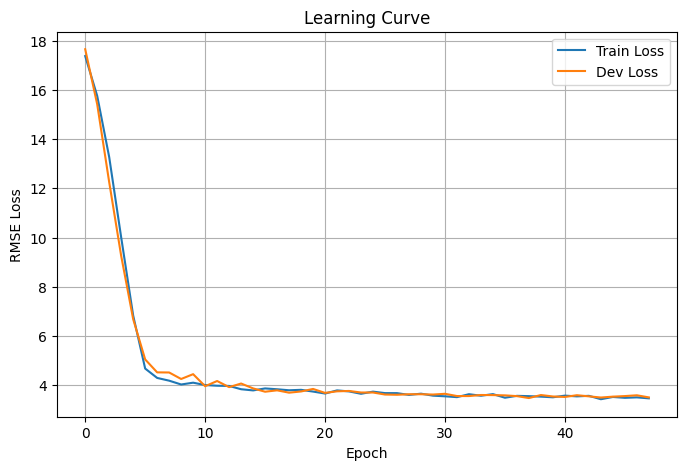

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_curve, label='Train Loss')
plt.plot(dev_curve, label='Dev Loss')

plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)

plt.show()

**Part 11 — Plot 2: Prediction vs Ground Truth**

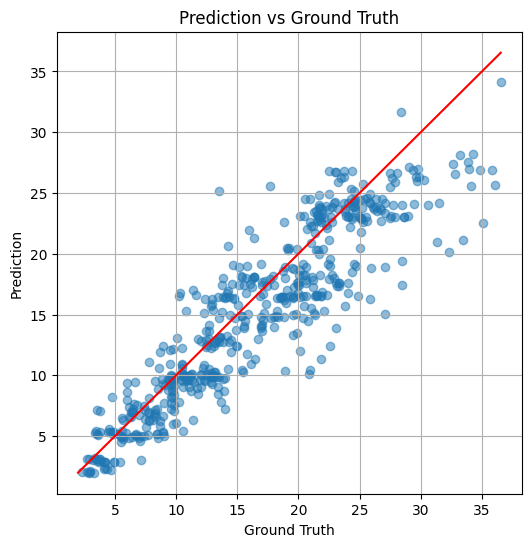

In [ ]:
model.eval()

preds, truths = [], []

with torch.no_grad():
    for x_batch, y_batch in dev_loader:
        x_batch = x_batch.to(device)
        pred = model(x_batch)

        preds.append(pred.cpu().numpy())
        truths.append(y_batch.numpy())

preds = np.concatenate(preds)
truths = np.concatenate(truths)

plt.figure(figsize=(6,6))
plt.scatter(truths, preds, alpha=0.5)

min_val = min(truths.min(), preds.min())
max_val = max(truths.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r')

plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Prediction vs Ground Truth')

plt.grid(True)
plt.show()

**Part 12 — Retrain on Full Data**

In [ ]:
full_loader = DataLoader(COVIDDataset(x, y), batch_size=128, shuffle=True)

model.load_state_dict(torch.load('best_model.pth'))

for epoch in range(10):
    model.train()
    for x_batch, y_batch in full_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        loss = criterion(model(x_batch), y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

**Part 13 — Prediction**

In [ ]:
model.eval()
preds = []

with torch.no_grad():
    for x_batch in test_loader:
        x_batch = x_batch.to(device)
        preds.append(model(x_batch).cpu().numpy())

preds = np.concatenate(preds)

with open('pred.csv', 'w') as f:
    f.write('id,tested_positive\n')
    for i, val in enumerate(preds):
        f.write(f'{i},{val}\n')

print("Prediction saved!")

Prediction saved!
